<u>Course Code</u>      : EE 414/517, CS 437/5317  
<u>Course Title</u>      : Deep Learning  
<u>Course Instructor</u> : Dr. Hassan Mohy-ud-Din  
<u>Co-Instructor</u>     : Muhammad Ibrahim Anwar, Mahad Amir

<u>Notebook Title</u>   : Assignment 1  
<u>Notebook Authors</u>  : Hassan Mohy-ud-Din  
<u>Correspondence</u>    : hassan.mohyuddin@lums.edu.pk

<u>Department</u>       : Department of Electrical Engineering  
<u>Institute</u>         : LUMS School of Science and Engineering, Lahore, Pakistan  
<u>Date</u>              : September 07, 2026  


# Deep Learning - Assignment # 1 (Notebook 1)
<!-- The objectives of this assignment are as follows:
- Learn the basics of univariate linear regression
- Enhance your understanding of **PyTorch** and **Torchvision** libraries (CLO4)
- Load pre-defined datasets **Torchvision** and perform different image **transformations** and **augmentations** (CLO3)
- Load and prepare **Custom Datasets** for your problem and **Dataloaders** for batch-sized training -->


## Setup Environment

In [2]:
import torch

import numpy                            as np
import matplotlib.pyplot                as plt

from sklearn.utils                      import shuffle
from sklearn.model_selection            import train_test_split
from sklearn.metrics                    import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors                  import ListedColormap
from torch.utils.data                   import Dataset, DataLoader
from torchvision.transforms             import ToTensor
from torchvision                        import datasets, transforms
from torchvision                        import datasets, transforms
from utils                              import compare_images

torch.manual_seed(42)
np.random.seed(42)

# Part 1: `Introduction to Pytorch` (20 Marks)

##### Welcome to PyTorch! In this section, you'll learn the fundamental building blocks of PyTorch that form the foundation of all deep learning operations.

### 1.1 Tensors basics (2 points)

In [3]:
## ---------------------------------------- UNDERSTAND AND RUN THE CODE BELOW ---------------------------------------- ##

# Example: Different ways to create tensors
example_zeros = torch.zeros(2, 3)
example_ones = torch.ones(2, 3)
example_random = torch.randn(2, 3)  # Sampling the values from standard Normal distribution
list_exam = [[1, 2, 3], [4, 5, 6]]
example_from_list = torch.tensor(list_exam)

print("Zeros tensor:\n", example_zeros)
print("\nOnes tensor:\n", example_ones)
print("\nRandom tensor:\n", example_random)
print("\nFrom list:\n", example_from_list)

Zeros tensor:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])

Ones tensor:
 tensor([[1., 1., 1.],
        [1., 1., 1.]])

Random tensor:
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863]])

From list:
 tensor([[1, 2, 3],
        [4, 5, 6]])


In [4]:
## ---------------------------------------- YOUR CODE STARTS HERE ---------------------------------------- ##

# TODO: Create a 3x4 tensor filled with zeros
zeros_tensor =torch.zeros(3, 4)

# TODO: Create a 2x3x5 tensor with random values from normal distribution
random_tensor =torch.randn(2, 3, 5)

# TODO: Create a tensor from this list: [[1, 2], [3, 4], [5, 6]]
list_tensor =torch.tensor([[1, 2], [3, 4], [5, 6]])

print(zeros_tensor)
print(random_tensor)
print(list_tensor)

## ---------------------------------------- YOUR CODE ENDS HERE ---------------------------------------- ##

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
tensor([[[-0.2483, -1.2082, -0.4777,  0.5201,  1.6423],
         [-0.1596, -0.4974,  0.4396,  2.0024,  0.4664],
         [ 1.5730, -0.9228,  1.2791,  1.2964,  1.5736]],

        [[-0.8455,  1.3123,  0.6872, -1.0892, -0.3553],
         [-0.9138, -0.6581,  0.0499,  2.2667,  1.1790],
         [-0.4345, -1.3864, -1.2862, -1.4032,  0.0360]]])
tensor([[1, 2],
        [3, 4],
        [5, 6]])


### 1.2 Understanding the Tensor properties (2 points)

In [5]:
## ---------------------------------------- UNDERSTAND AND RUN THE CODE BELOW ---------------------------------------- ##

sample_tensor = torch.randn(2, 3, 4)
print("Sample tensor:\n", sample_tensor)

print(f"\n{"-"*30} Basic Properties {"-"*30}")
print("Shape (size):", sample_tensor.shape)
print("Data type:", sample_tensor.dtype)
print("Device:", sample_tensor.device)
print("Number of dimensions:", sample_tensor.ndim)
print("Total number of elements:", sample_tensor.numel())
print(f"{"-"*80}")


Sample tensor:
 tensor([[[ 1.8113,  0.1606,  0.3672,  0.1754],
         [ 1.3852, -0.4459,  1.4451,  0.8564],
         [-1.3407, -0.5854,  0.5362,  0.5246]],

        [[ 1.1412,  0.0516,  0.7281, -0.7106],
         [-1.0495,  0.6039, -1.7223, -0.8278],
         [ 1.3347,  0.4835, -0.1976,  1.2683]]])

------------------------------ Basic Properties ------------------------------
Shape (size): torch.Size([2, 3, 4])
Data type: torch.float32
Device: cpu
Number of dimensions: 3
Total number of elements: 24
--------------------------------------------------------------------------------


In [6]:
# ------------------------------------- YOUR CODE STARTS HERE -------------------------------------- #

test_tensor = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])

# TODO: Extract the following properties of test_tensor
tensor_shape =test_tensor.shape  # Get the shape
tensor_dtype =test_tensor.dtype                             # Get the data type
tensor_device =test_tensor.device                            # Get the device
tensor_ndim =test_tensor.ndim                              # Get number of dimensions
tensor_numel =test_tensor.numel()                             # Get total number of elements

print(tensor_shape)
print(tensor_dtype)
print(tensor_device)
print(tensor_ndim)
print(tensor_numel)

# TODO: Perform the following operations
transposed_tensor =test_tensor.T                        # Transpose the tensor (hint: use .T or .transpose())
flattened_tensor =test_tensor.flatten()                         # Flatten to 1D (hint: use .flatten())
print(transposed_tensor)
print(flattened_tensor)

# TODO: Element-wise operations
doubled_tensor =test_tensor*2                           # Multiply each element by 2
squared_tensor =test_tensor**2                           # Square each element
sum_result =test_tensor.sum()                               # Sum of all elements
print(doubled_tensor)
print(squared_tensor)
print(sum_result)

## ---------------------------------------- YOUR CODE ENDS HERE ---------------------------------------- ##

torch.Size([2, 3])
torch.float32
cpu
2
6
tensor([[1., 4.],
        [2., 5.],
        [3., 6.]])
tensor([1., 2., 3., 4., 5., 6.])
tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.]])
tensor([[ 1.,  4.,  9.],
        [16., 25., 36.]])
tensor(21.)


### 1.3 Shape Manupulation of Tensors (3 points)

In [7]:
## ---------------------------------------- UNDERSTAND AND RUN THE CODE BELOW ---------------------------------------- ##

print(f"\n{"-"*30} Shape Manupulation {"-"*30}\n")

# Starting tensor
original = torch.arange(24)  # [0, 1, 2, ..., 23]
print("Original tensor:", original.shape)


# Different ways to reshape (Note that the total number of elements should remain equal before and after the reshape):

view_result = original.view(4, 6)                              # Doesnot change the tensor
reshape_result = original.reshape(2, 3, 4)                     # Changes the tesnor
print("View shape:", view_result.shape)
print("Reshape shape:", reshape_result.shape)

# Squeeze and unsqueeze
squeezed = torch.randn(1, 3, 1, 4)
print("Before squeeze:", squeezed.shape)
print("After squeeze:", squeezed.squeeze().shape)              # Removes dimensions of size 1


unsqueezed = torch.randn(3, 4)
print("Before unsqueeze:", unsqueezed.shape)
print("After unsqueeze(0):", unsqueezed.unsqueeze(0).shape)    # Adds dimension at position 0


------------------------------ Shape Manupulation ------------------------------

Original tensor: torch.Size([24])
View shape: torch.Size([4, 6])
Reshape shape: torch.Size([2, 3, 4])
Before squeeze: torch.Size([1, 3, 1, 4])
After squeeze: torch.Size([3, 4])
Before unsqueeze: torch.Size([3, 4])
After unsqueeze(0): torch.Size([1, 3, 4])


In [8]:
## ---------------------------------------- UNDERSTAND THE CODE BELOW ---------------------------------------- ##

# Starting tensors for exercises
tensor_24 = torch.arange(24)                                   # Shape: [24]
tensor_2x3x4 = torch.randn(2, 3, 4)                            # Shape: [2, 3, 4]
tensor_with_ones = torch.randn(1, 5, 1, 3, 1)                  # Shape: [1, 5, 1, 3, 1]

# TODO: Complete the shape manipulation tasks

# Task 1: Reshape tensor_24 to different shapes
print(tensor_24)
shape_4x6 =tensor_24.view(4, 6)                                               # Reshape to [4, 6]
shape_2x3x4 =tensor_24.view(2, 3, 4)                                             # Reshape to [2, 3, 4]
shape_24x1 =tensor_24.view(24, 1)                                              # Reshape to [24, 1]
print(shape_4x6)
print(shape_2x3x4)
print(shape_24x1)

# Task 3: Squeeze operations
squeezed_all =tensor_with_ones.squeeze()                                            # Remove all dimensions of size 1 from tensor_with_ones
squeezed_dim0 =tensor_with_ones.squeeze(0)                                           # Remove only dimension 0 from tensor_with_ones (if size 1)
squeezed_dim2 =tensor_with_ones.squeeze(2)                                          # Remove only dimension 2 from tensor_with_ones (if size 1)
print(squeezed_all)
print(squeezed_dim0)
print(squeezed_dim2)

# Task 4: Unsqueeze operations
original_2d = torch.randn(3, 4)
unsqueezed_dim0 =original_2d.unsqueeze(0)                                         # Add dimension at position 0: [3, 4] -> [1, 3, 4]
unsqueezed_dim1 =original_2d.unsqueeze(1)                                         # Add dimension at position 1: [3, 4] -> [3, 1, 4]
unsqueezed_last =original_2d.unsqueeze(-1)                                         # Add dimension at the end: [3, 4] -> [3, 4, 1]
print(unsqueezed_dim0)
print(unsqueezed_dim1)
print(unsqueezed_last)

# ------------------------------------- YOUR CODE ENDS HERE -------------------------------------- #

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23])
tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17],
        [18, 19, 20, 21, 22, 23]])
tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])
tensor([[ 0],
        [ 1],
        [ 2],
        [ 3],
        [ 4],
        [ 5],
        [ 6],
        [ 7],
        [ 8],
        [ 9],
        [10],
        [11],
        [12],
        [13],
        [14],
        [15],
        [16],
        [17],
        [18],
        [19],
        [20],
        [21],
        [22],
        [23]])
tensor([[-2.3768,  0.0641, -0.3435],
        [ 1.2287, -0.2754, -0.2109],
        [ 0.9287, -0.2282, -1.2179],
        [ 1.3214, -1.4594, -0.5025],
        [-1.0614, -0.3485, -0.8923]])
tensor([[[[-2.3768],
          [ 0.0641],
          [-0.3435]

### 1.4 Broadcasting Rules (3 points)

Broadcasting allows operations between tensors of different shapes. In the background, Pytorch library overloads the  `+`, `-`, `*`, `/` operators.

In [9]:
## ---------------------------------------- UNDERSTAND AND RUN THE CODE BELOW ---------------------------------------- ##

print(f"\n{"-"*30} Broadcasting Rules {"-"*30}\n")

# Broadcasting examples
print("\nExample 1: Scalar with tensor \n")
tensor_a = torch.tensor([[1, 2, 3], [4, 5, 6]])                 # Shape: [2, 3]
scalar = 10
result1 = tensor_a + scalar

print(f"{tensor_a} + {scalar} \n= {result1}")


print("\nExample 2: Different shaped tensors\n")
tensor_b = torch.tensor([[1], [2]])                             # Shape: [2, 1]
tensor_c = torch.tensor([10, 20, 30])                           # Shape: [3]
result2 = tensor_b + tensor_c
print(f"{tensor_b} + {tensor_c} \n= {result2}")



print("\n Broadcasting Rules:")
print("1. Start from the trailing dimension")
print("2. Dimensions are compatible if they are equal or one of them is 1")
print("3. Missing dimensions are assumed to be 1")


------------------------------ Broadcasting Rules ------------------------------


Example 1: Scalar with tensor 

tensor([[1, 2, 3],
        [4, 5, 6]]) + 10 
= tensor([[11, 12, 13],
        [14, 15, 16]])

Example 2: Different shaped tensors

tensor([[1],
        [2]]) + tensor([10, 20, 30]) 
= tensor([[11, 21, 31],
        [12, 22, 32]])

 Broadcasting Rules:
1. Start from the trailing dimension
2. Dimensions are compatible if they are equal or one of them is 1
3. Missing dimensions are assumed to be 1


In [10]:
## ---------------------------------------- YOUR CODE STARTS HERE ---------------------------------------- ##

# Given tensors
tensor_2x3 = torch.tensor([[1, 2, 3], [4, 5, 6]])               # Shape: [2, 3]
tensor_2x1 = torch.tensor([[10], [20]])                         # Shape: [2, 1]
tensor_3 = torch.tensor([100, 200, 300])                        # Shape: [3]
scalar_value = 5


# Task 1: Broadcasting with scalar
broadcast_scalar =tensor_2x3+scalar_value                                         # Add scalar_value to tensor_2x3
print(broadcast_scalar)

# Task 2: Broadcasting compatible tensors
broadcast_2x1_with_2x3 =tensor_2x1+tensor_2x3                                  # Add tensor_2x1 to tensor_2x3
broadcast_3_with_2x3 =tensor_3+tensor_2x3                                     # Add tensor_3 to tensor_2x3
print(broadcast_2x1_with_2x3)
print(broadcast_3_with_2x3)

# Task 3: Chain broadcasting operations
chain_broadcast =tensor_2x3+tensor_2x1+tensor_3                                          # Add all three: tensor_2x3 + tensor_2x1 + tensor_3
print(chain_broadcast)


# Task 4: Element-wise operations with broadcasting
element_multiply =tensor_2x3*tensor_2x1                                         # Multiply tensor_2x3 by tensor_2x1 (element-wise)
print(element_multiply)


# Task 5: Understanding broadcast failures
# Try to predict which of these will fail:
try:
    tensor_2x3_test = torch.randn(2, 3)
    tensor_4x1_test = torch.randn(4, 1)

    # Should this give error or not? - uncomment the line below to test:
    result_test = tensor_2x3_test + tensor_4x1_test

    print("Would [2,3] + [4,1] work? Think about it, then uncomment to test!")
except RuntimeError as e:
    print(f"Broadcasting failed as expected: {e}")

## ---------------------------------------- YOUR CODE ENDS HERE ---------------------------------------- ##

tensor([[ 6,  7,  8],
        [ 9, 10, 11]])
tensor([[11, 12, 13],
        [24, 25, 26]])
tensor([[101, 202, 303],
        [104, 205, 306]])
tensor([[111, 212, 313],
        [124, 225, 326]])
tensor([[ 10,  20,  30],
        [ 80, 100, 120]])
Broadcasting failed as expected: The size of tensor a (2) must match the size of tensor b (4) at non-singleton dimension 0


### 1.5 Gradient Computation Basics (5 points)

PyTorch's automatic differentiation system (autograd) is what makes neural network training possible. It automatically computes gradients of tensors with respect to some scalar value.

#### Key Concepts:
- **requires_grad**: Tells PyTorch to track operations on a tensor
- **grad**: Stores the gradient of a tensor  
- **backward()**: Computes gradients via backpropagation
- **Computational Graph**: PyTorch builds a graph of operations for gradient computation

#### Why This Matters:
In neural networks, we need gradients to update weights using algorithms like gradient descent.

In [11]:
## ---------------------------------------- UNDERSTAND THE CODE BELOW ---------------------------------------- ##

print(f"\n{'-'*30} Automatic Gradient (Autograd) {'-'*30}\n")

# Example: Simple function f(x) = x^2 + 2x + 1
print("Example: f(x) = x^2 + 2x + 1\n")

# Create a tensor x = 3.0 and tell PyTorch to track its gradient
x = torch.tensor(3.0, requires_grad=True)
print(f"x = {x}")
print(f"x.requires_grad = {x.requires_grad}")                   # True. PyTorch will now track operations on this tensor so we can compute derivatives automatically later


# Forward pass i.e. compute y = f(x)
y = x**2 + 2*x + 1
print(f"y = f(x) = {y}")
print(f"y.requires_grad = {y.requires_grad}")                   # True, since y depends on x (y inherits from x)

# Backward pass: compute derivative dy/dx
y.backward()                                                    # Computes gradient using autograd
print(f"dy/dx = x.grad = {x.grad}")                             # Gradient stored in x.grad

# Manual check of derivative at x=3
print(f"Expected: dy/dx = 2x + 2 = 2(3) + 2 = {2*3 + 2}")



------------------------------ Automatic Gradient (Autograd) ------------------------------

Example: f(x) = x^2 + 2x + 1

x = 3.0
x.requires_grad = True
y = f(x) = 16.0
y.requires_grad = True
dy/dx = x.grad = 8.0
Expected: dy/dx = 2x + 2 = 2(3) + 2 = 8


In [12]:
## ---------------------------------------- YOUR CODE STARTS HERE ---------------------------------------- ##

# Task 1: Simple quadratic function

# Given: f(x) = 3x^2 + 4x - 5, find gradient at x = 2.0
x1 =torch.tensor(2.0, requires_grad=True)                                                       # Create tensor with value 2.0 and requires_grad=True
y1 =3*x1**2+4*x1-5                                        # Compute f(x1) = 3*x1^2 + 4*x1 - 5
print(y1)

# Don't compute backward yet - we'll do it in verification


# Task 2: Multi-variable function

# Given: f(a,b) = a^2 * b + a * b^2, find gradients at a=1.0, b=2.0
a =torch.tensor(1.0, requires_grad=True)                      # Create tensor with value 1.0 and requires_grad=True
b =torch.tensor(2.0, requires_grad=True)                      # Create tensor with value 2.0 and requires_grad=True
z =a**2*b+a*b**2                                        # Compute f(a,b) = a^2 * b + a * b^2
print(z)
# Don't compute backward yet


# Task 3: Chain rule demonstration

# Given: h(x) = sin(x^2), find gradient at x = π/4
x3 =torch.tensor(torch.pi/4, requires_grad=True)              # Create tensor with value π/4 and requires_grad=True
h =torch.sin(x3**2)                                           # Compute h(x3) = sin(x3^2)
print(h)
# Don't compute backward yet

## ---------------------------------------- YOUR CODE ENDS HERE ---------------------------------------- ##


tensor(15., grad_fn=<SubBackward0>)
tensor(6., grad_fn=<AddBackward0>)
tensor(0.5785, grad_fn=<SinBackward0>)


### 1.6 Gradient Flow and Management (5 points)

In [13]:
## ---------------------------------------- UNDERSTAND AND RUN THE CODE BELOW ---------------------------------------- ##

print(f"\n{'-'*30} Gradient Flow and Management {'-'*30}\n")
print("Understanding Gradient Accumulation: \n")

# Gradients accumulate by default!
x = torch.tensor(1.0, requires_grad=True)

# First computation
y1 = x * 2
y1.backward()
print(f"After first backward: x.grad = {x.grad}")


# Second computation - gradients accumulate!
y2 = x * 3
y2.backward()
print(f"After second backward: x.grad = {x.grad}")              # Should be 2 + 3 = 5


# Clear gradients
x.grad.zero_()                                                  # or x.grad = None
print(f"After zero_grad: x.grad = {x.grad}")

print("\nStopping Gradient Flow: \n")
x = torch.tensor(2.0, requires_grad=True)
y = x * 2

# Method 1: detach()
y_detached = y.detach()                                         # Stops gradient flow
z1 = y_detached * 3                                             # z1 won't have gradients

# Method 2: with torch.no_grad()
with torch.no_grad():
    z2 = y * 4                                                  # z2 won't have gradient (only for this particular block of code. It may have it later on.)

print(f"y.requires_grad = {y.requires_grad}")
print(f"y_detached.requires_grad = {y_detached.requires_grad}")
print(f"z2.requires_grad = {z2.requires_grad}")



------------------------------ Gradient Flow and Management ------------------------------

Understanding Gradient Accumulation: 

After first backward: x.grad = 2.0
After second backward: x.grad = 5.0
After zero_grad: x.grad = 0.0

Stopping Gradient Flow: 

y.requires_grad = True
y_detached.requires_grad = False
z2.requires_grad = False


In [14]:
## ---------------------------------------- YOUR CODE STARTS HERE ---------------------------------------- ##

# Task 1: Gradient accumulation
x_accum = torch.tensor(2.0, requires_grad=True)

# Perform three separate computations and let gradients accumulate
computation1 =x_accum**2
computation1.backward()
print(x_accum.grad)                                   # x_accum^2, then backward()
computation2 = x_accum**3                                         # x_accum^3, then backward()
computation2.backward()
print(x_accum.grad)                                   # x_accum^3, then backward()
computation3 = x_accum * 4                                         # x_accum * 4, then backward()
computation3.backward()
print(x_accum.grad)                                   # x_accum * 4, then backward()



# Task 2: Gradient clearing
# After the accumulations above, clear the gradients
x_accum.grad.zero_()
print(x_accum.grad)                                        # Clear x_accum.grad

# Task 3: Stopping gradients
x_stop =torch.tensor(3.0, requires_grad=True)
intermediate=x_stop**2+1
print(intermediate.requires_grad)

# Create two versions:
with_grad = intermediate * 2                                # Keep gradients: intermediate * 2
print(with_grad.requires_grad)
without_grad = intermediate.detach()                        # Stop gradients: use .detach() or torch.no_grad()
print(without_grad.requires_grad)

## ---------------------------------------- YOUR CODE ENDS HERE ---------------------------------------- ##

tensor(4.)
tensor(16.)
tensor(20.)
tensor(0.)
True
True
False


---

# Part 2: `Torchvision Datasets` (30 points)

Before getting started with the implementation of this code, you need to be familiar with the PyTorch computer vision library: `Torchvision`

| PyTorch module | What does it do? |
| ----- | ----- |
| [torchvision](https://pytorch.org/vision/stable/index.html) | Contains datasets, model architectures and image transformations often used for computer vision problems. |
| [torchvision.datasets](https://pytorch.org/vision/stable/datasets.html) | Here you'll find many example computer vision datasets for a range of problems from image classification, object detection, image captioning, video classification and more. It also contains [a series of base classes for making custom datasets](https://pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets). |
| [torchvision.models](https://pytorch.org/vision/stable/models.html) | This module contains well-performing and commonly used computer vision model architectures implemented in PyTorch, you can use these with your own problems. |
| [torchvision.transforms](https://pytorch.org/vision/stable/transforms.html) | Often images need to be transformed (turned into numbers/processed/augmented) before being used with a model, common image transformations are found here. |
| [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) | Base dataset class for PyTorch.  |
| [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#module-torch.utils.data) | Creates a Python iterable over a dataset (created with torch.utils.data.Dataset). |

> **Note:** The `torch.utlis.data.Dataset` and `torch.utils.data.DataLoader` classes aren't only for computer vision in PyTorch, they are capable of dealing with many different types of data.

## 2.1 Load Datasets (2 points)

We are doing to load the *train* split of **3 datasets** from [`torchvision.datasets`](https://pytorch.org/vision/main/datasets.html), namely:
* `MNIST`: A collection of handwritten digits ranging from the number $0$ to $9$
* `FashionMNIST`: A dataset comprising of $28\times28$ grayscale images of fashion products from different categories
* `CIFAR-10`: A dataset containing $32\times32$ color images from $10$ different classes representing airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks

In [15]:
# TODO -- Use torchvision.datasets to load the training splits of each of the datasets mentioned above
# TODO -- Use the datasets.MNIST, datasets.FashionMNIST, and datasets.CIFAR10 classes
# TODO -- set the paramater: transform=ToTensor()

## ------------------------Your code begins here ------------------------------- ##
# Setup training data
mnist_train =datasets.MNIST(root='./data', train=True, download=True, transform=ToTensor())
fmnist_train =datasets.FashionMNIST(root='./data', train=True, download=True, transform=ToTensor())
cifar10_train =datasets.CIFAR10(root='./data', train=True, download=True, transform=ToTensor())
## ------------------------Your code ends here---------------------------------- ##

# TODO -- Compute the size (length) and extract classes from each of the datasets

## ------------------------Your code begins here ------------------------------- ##
# Store length of each dataset in a variable
mnist_train_len =len(mnist_train)
fmnist_train_len =len(fmnist_train)
cifar10_train_len =len(cifar10_train)

# Store classes for each dataset in a variable
mnist_classes =mnist_train.classes
fmnist_classes =fmnist_train.classes
cifar10_classes =cifar10_train.classes
## ------------------------Your code ends here---------------------------------- ##

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 506kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.29MB/s]
100%|██████████| 26.4M/26.4M [00:02<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 206kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.74MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 6.21MB/s]
100%|██████████| 170M/170M [26:42<00:00, 106kB/s]


In [16]:
# ----------------------------- DONOT MODIFY CODE BELOW THIS LINE ---------------------------------- #
print(f"MNIST Dataset:\nTrain size: {mnist_train_len} samples\nClasses: {mnist_classes}")
print('-' * 50)
print(f"FashionMNIST Dataset:\nTrain size: {fmnist_train_len} samples\nClasses: {fmnist_classes}")
print('-' * 50)
print(f"CIFAR-10 Dataset:\nTrain size: {cifar10_train_len} samples\nClasses: {cifar10_classes}")

MNIST Dataset:
Train size: 60000 samples
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
--------------------------------------------------
FashionMNIST Dataset:
Train size: 60000 samples
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
--------------------------------------------------
CIFAR-10 Dataset:
Train size: 50000 samples
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2.2 Data Visualization (4 points)

An important aspect of understanding any dataset is visualising different examples present in it. Accordingly, in this section we are going to visualize a **batch** of samples from each of the datasets extracted in the above section.

**Hint:** *It may be helpful to check for the number of channels before displaying images. Tensor images are usually stored in the format `[c, h, w]` (channels first) while `matplotlib.pyplot.imshow()` accepts images in `[h, w, c]` (channels last) format*.

In [17]:
def visualize(dataset: torch.utils.data.Dataset, dataset_name: str, class_names: list, items: int=16):
    """
    Visualize a random sample of images from the given dataset.

    Args:
        dataset (torch.utils.data.Dataset): the dataset containing the images.
        dataset_name (str): the name of the dataset.
        class_names (list): The list of class names corresponding to the labels
        items (int): The number of items to visualize. Default
    Returns:
        None
    """
    torch.manual_seed(0)
    fig  = plt.figure(figsize=(15, 4))
    rows = 2
    cols = items // rows

    for i in range(1, items + 1):

        # TODO -- Select a random integer using torch.randint() (or any equivalent method) between 0 to len(dataset)
        ranint=torch.randint(0, len(dataset), (1,)).item()

        # TODO -- Use the random integer to select a random image and its corresponding label from the dataset

        ## ------------------------Your code begins here-------------------------------- ##
        img, label =dataset[ranint]
        ## ------------------------Your code ends here---------------------------------- ##

        fig.add_subplot(rows, cols, i)

        # TODO: Check the number of channels in the image.
        # TODO: If no. of channels are 1, use plt.imshow(image.squeeze(), cmap='gray'), else use plt.imshow(image.permute(1, 2, 0))
        if img.shape[0]==1:
            plt.imshow(img.squeeze(), cmap='gray')
        else:
            plt.imshow(img.permute(1, 2, 0))
        ## ------------------------Your code begins here-------------------------------- ##

        ## ------------------------Your code ends here---------------------------------- ##

# ------------------------------- DONOT MODIFY CODE BELOW THIS LINE ------------------------------------------ #
        plt.title(f"Class:{class_names[label]}\nShape:{list(img.shape)}", fontsize=8)
        plt.axis('off')

    plt.suptitle(dataset_name, fontweight="bold")
    plt.tight_layout()
    plt.show()

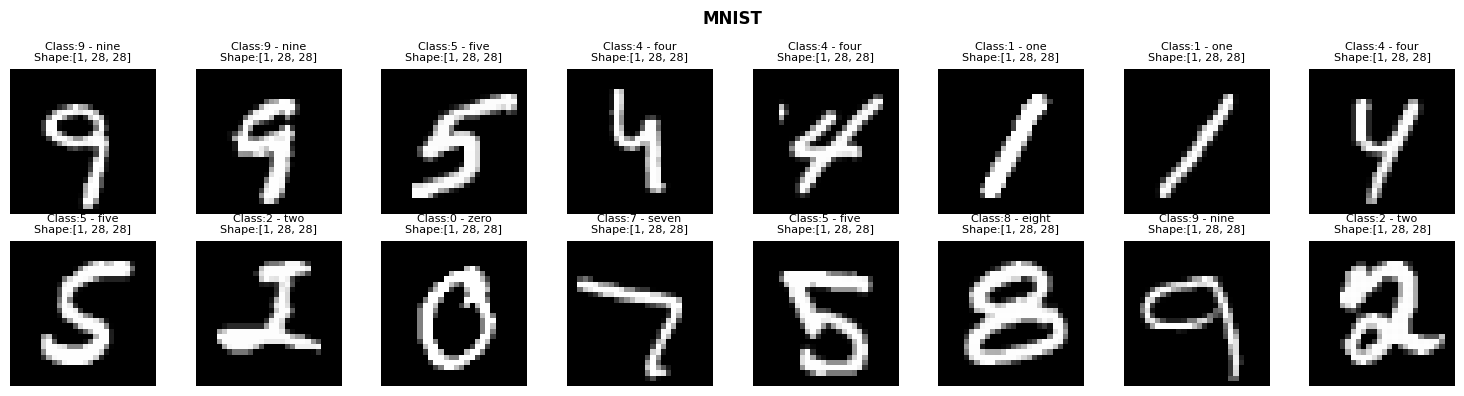

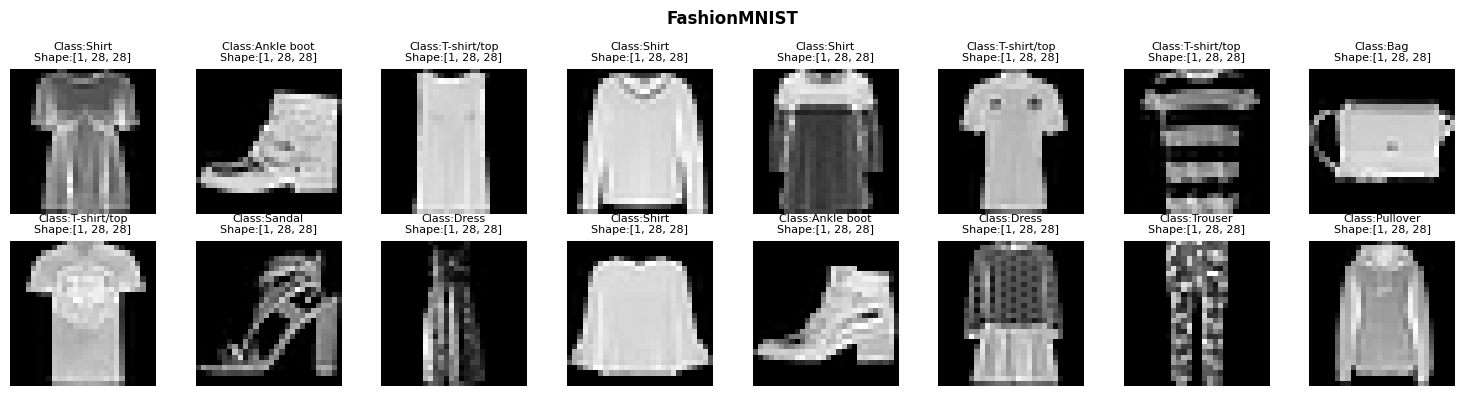

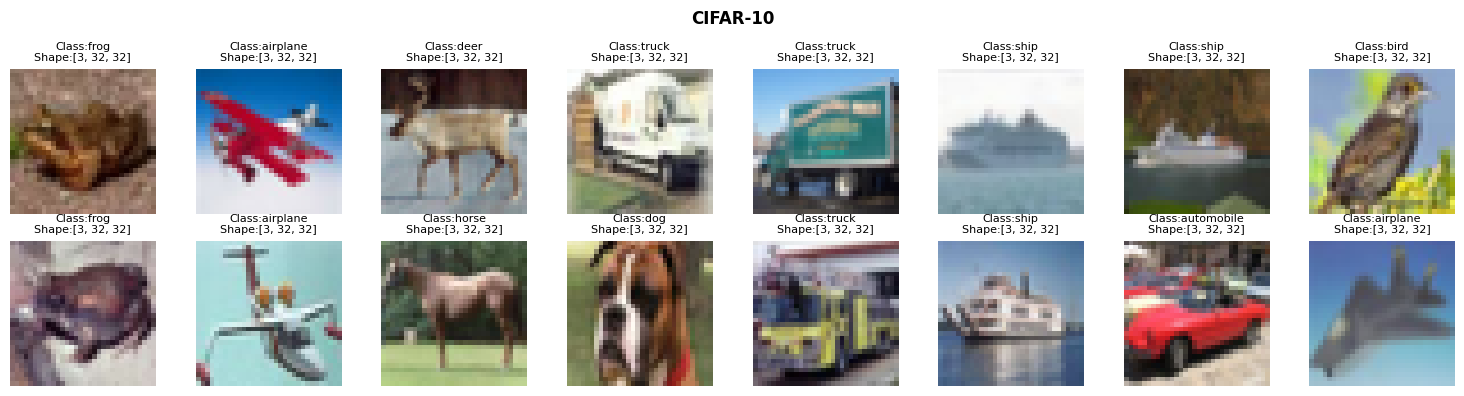

In [18]:
# ------------------------------------- DONOT MODIFY CODE BELOW THIS LINE -------------------------------------- #
# Iterate over each dataset and its corresponding classes
dataset_list = [(mnist_train, mnist_classes), (fmnist_train, fmnist_classes), (cifar10_train, cifar10_classes)]
dataset_names = ["MNIST", "FashionMNIST", "CIFAR-10"]
for name, (dataset, class_names_list) in zip(dataset_names, dataset_list):
    # Call the visualize function to visualize a random sample of images from the dataset
    visualize(dataset, name, class_names_list)

## 2.3 Compare and Contrast (4 points)

**Analyze the differences in image characteristics (e.g., color channels, image size) among the three datasets.** <br>
<span style="color:green;"> *Your response here* </span>

**Discuss how these differences might affect preprocessing steps for Deep Learning tasks?**<br>
<span style="color:green;"> *Your response here* </span>

## 2.4 Data Transformation and Augmentation - CLO3 (15 points)

Data transformation is a crucial step in preparing data for deep learning models. It involves various techniques to preprocess and augment the data, ensuring that the model can learn effectively. Here are some common data transformation techniques:

| Technique              | Description                                                                                                                                                       |
|------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Normalization**      | This process scales the pixel values of images to a standard range, typically [0, 1] or [-1, 1]. Normalization helps in faster convergence during training and can improve model performance. |
| **Rescaling**          | Rescaling adjusts the size of the images to a fixed dimension, which is necessary for feeding images into a neural network.                                        |
| **Centering**          | This involves subtracting the mean of the dataset from each image, which helps in reducing the bias in the data.                                                   |
| **Standardization**    | This technique scales the data to have a mean of zero and a standard deviation of one. It is particularly useful when the features have different units or scales.  |
| **Data Augmentation**  | This includes techniques like random cropping, flipping, rotation, and color jittering to artificially increase the size of the training dataset and improve the model's generalization. |
| **Grayscale Conversion** | Converting RGB images to grayscale can be useful for certain tasks where color information is not important.                                                      |
| **Tensor Conversion**  | Converting images to tensors is necessary for processing them with deep learning frameworks like PyTorch.                                                          |

By applying these transformations, you can ensure that your data is in the best possible shape for training a deep learning model, leading to better performance and more robust models.

**Note:** For this section we are going to perform a subset of these transformations on `CIFAR-10` dataset due to its *interesting* `RGB` format.

### 2.4.1 Rescaling (1.5 points)
We will begin by defining a simple transform for **rescaling (resizing)** a given input image from size [3, 32, 32] to **size [3, 16, 16]** using [`torchvision.transforms.Resize()`](https://pytorch.org/vision/main/generated/torchvision.transforms.Resize.html) method.

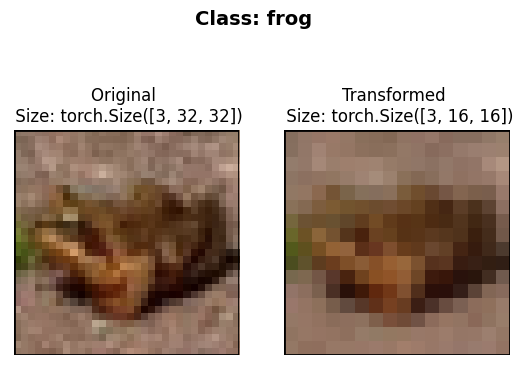

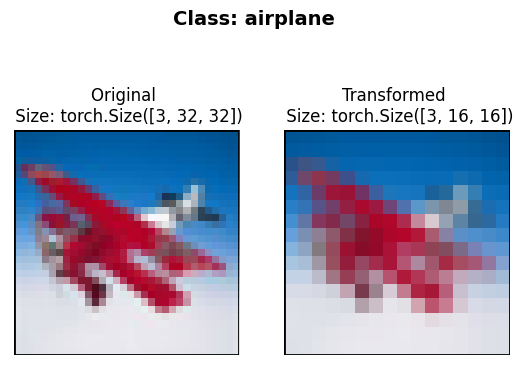

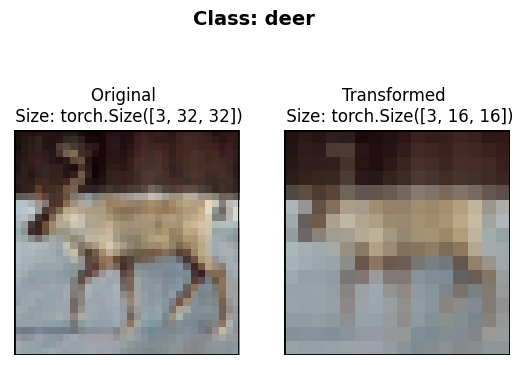

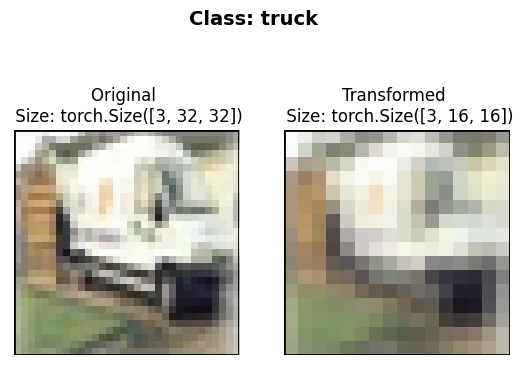

In [19]:
# TODO - Define a transformation for the images to resize the images to torch.Size([3,16,16])

## ------------------------Your code begins here--------------------------------##
resize =transforms.Resize((16, 16))
## ------------------------Your code ends here----------------------------------##

# ----------------------------- DONOT MODIFY CODE BELOW THIS LINE ---------------------------------- #
compare_images(cifar10_train, resize, cifar10_classes)

### 2.4.2 Grayscale Conversion (1.5 points)
Next, we will convert the RGB channels to a **single channel (e.g., grayscaling)** using [`torchvision.transforms.Grayscale()`](https://pytorch.org/vision/stable/generated/torchvision.transforms.Grayscale.html) method.

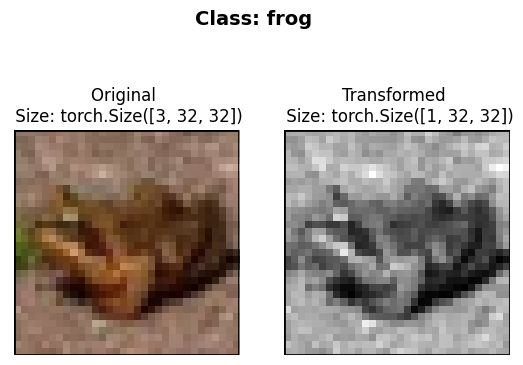

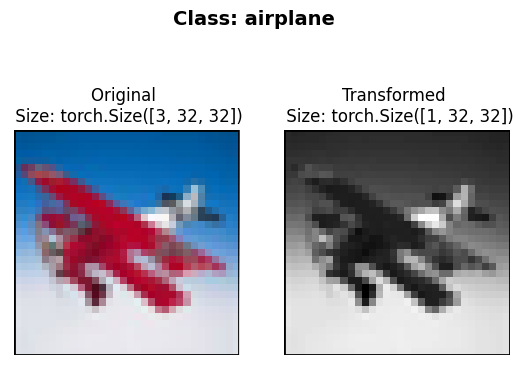

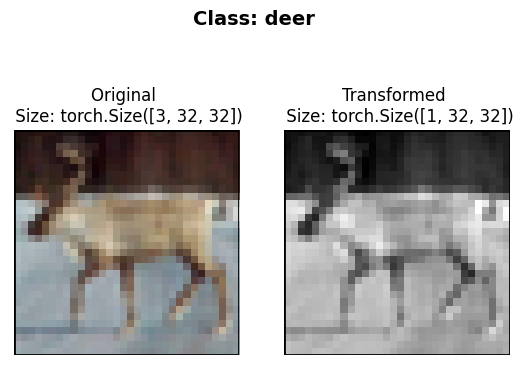

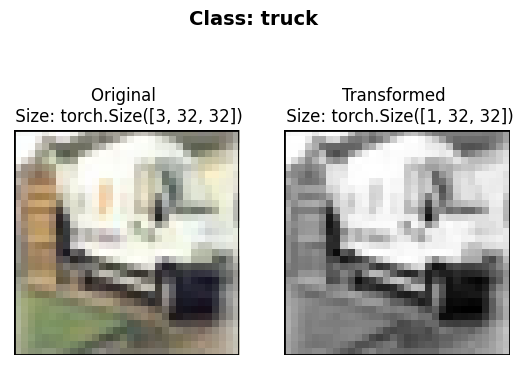

In [20]:
# TODO - Define a transformation for the images to grayscale

## ------------------------Your code begins here--------------------------------##
grayscale =transforms.Grayscale()
## ------------------------Your code ends here----------------------------------##

# ----------------------------- DONOT MODIFY CODE BELOW THIS LINE ---------------------------------- #
compare_images(cifar10_train, grayscale, cifar10_classes)

### 2.4.3 Normalization (6 points)
#### Z-Score Normalization (3 points)
Now we will perform **Z-Score Normalization** using [`torchvision.transforms.Normalize()`](https://pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html). <br>
This involves calculating the *mean* and *standard deviation* of each channel and subtracting these values from individual pixels of the corresponding channel that is:
$$
I_{i,j,k} = \frac{I_{i,j,k}-\mu_{k}}{\sigma_{k}}
$$
where, $I$ is the image, $k$ is the channel number and $i$, $j$ are the pixels (rows and columns) of the corresponding channel. Here $\mu_k$ and $\sigma_k$ are mean and std deviation of channel $k$.


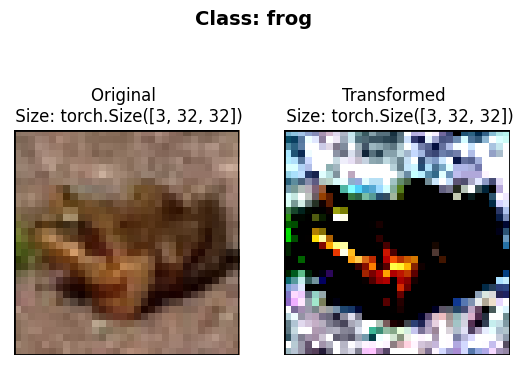

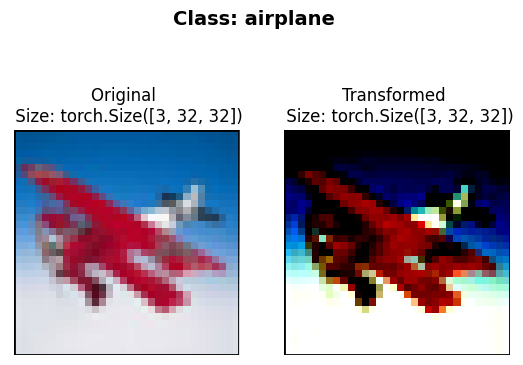

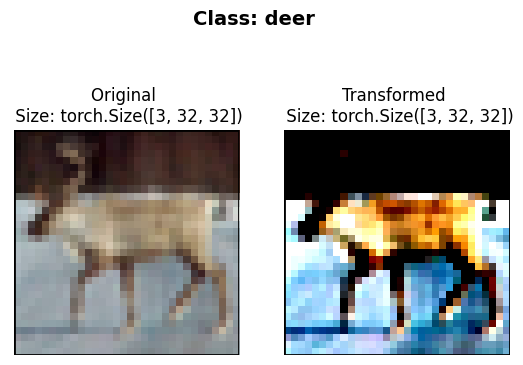

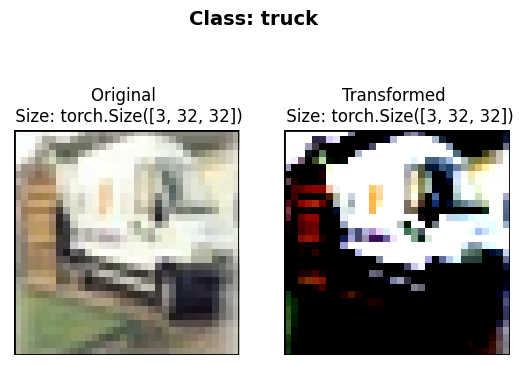

In [21]:
def z_normalization(image: torch.Tensor) -> torch.Tensor:
    """
    Normalize the image using Z-score normalization.

    Args:
        image (torch.Tensor): The input image tensor.
    Returns:
        torch.Tensor: The z-score normalized image tensor.
    """
    # TODO - Compute the mean and standard deviation of the image tensor for each channel
    # TODO - Pass these values to the torchvision.transforms.Normalize() function as arguments
    # TODO - Apply the transform on image

    ## ------------------------Your code begins here -------------------------------##
    means =image.mean(dim=(1, 2))
    stds =image.std(dim=(1, 2))
    z_transform =transforms.Normalize(mean=means, std=stds)
    normalized_image =z_transform(image)
    ## ------------------------Your code ends here----------------------------------##

    return normalized_image

# ----------------------------- DONOT MODIFY CODE BELOW THIS LINE ---------------------------------- #
# note: expect truncation warning!
compare_images(cifar10_train, z_normalization, cifar10_classes)

#### Min/Max Normalization (3 points)
Here we will perform Min/Max normalization using the following equation.<br> This involves calculating the min and max values of each channel and applying the following formula on each pixel of the corresponding channel:
$$
I_{i,j,k} = \frac{I_{i,j,k} - I_{k_{\text{min}}}}{I_{k_{\text{max}}} - I_{k_{\text{min}}}}
$$
where $I_{k_{\text{min}}}$ and $I_{k_{\text{max}}}$ are the *minimum* and *maximum* values of channel $k$ respectively.

> **Note**: *We are not using any torchvision.transform method here.*

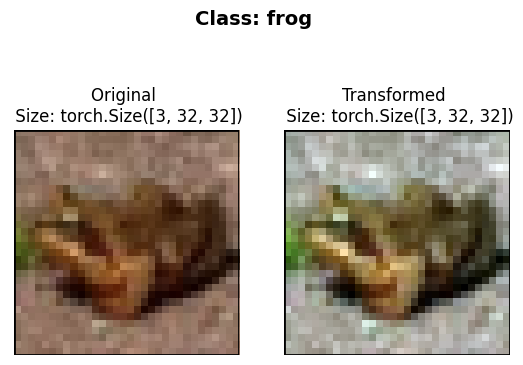

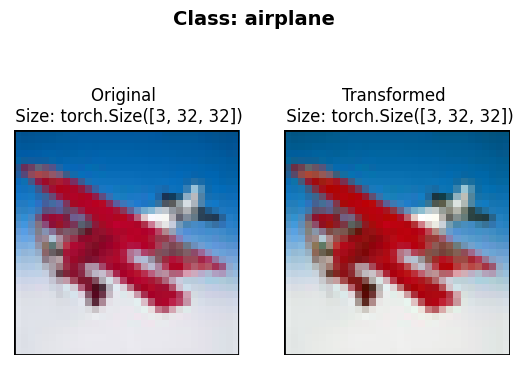

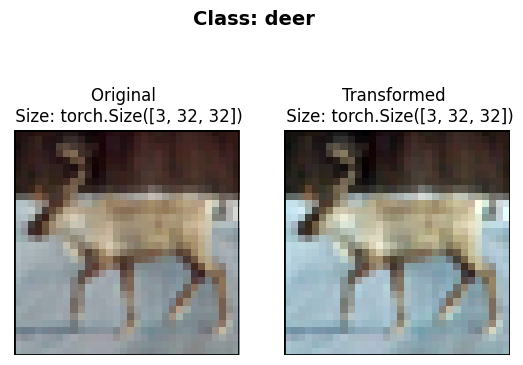

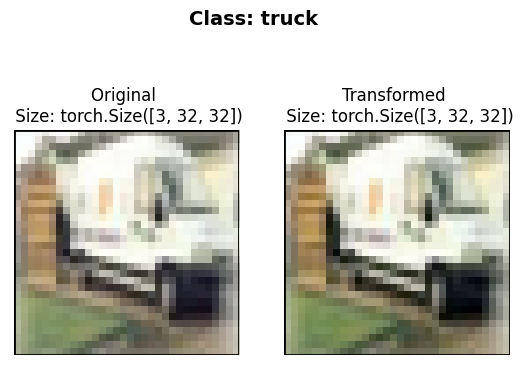

In [24]:
def min_max_normalization(image: torch.Tensor) -> torch.Tensor:
    """
    Normalize the image using min_max normalization.

    Args:
        image (torch.Tensor): The input image tensor.
    Returns:
        torch.Tensor: The min_max normalized image tensor.
    """
    # TODO - Compute the minimum and maximum value of the image tensor for each channel
    # TODO - Reshape these tensors to torch.Size([3, 32, 32]) (Hint: Each channel of shape [32, 32] should store same value for each entry coming from 'mins' and 'max')
    # TODO - Finally, apply the above equation to get the transformed image

    ## ------------------------Your code begins here -------------------------------##
    mins =image.amin(dim=(1, 2))
    maxs =image.amax(dim=(1, 2))

    mins_reshaped =mins.view(-1, 1, 1).expand_as(image)
    maxs_reshaped =maxs.view(-1, 1, 1).expand_as(image)

    normalized_image =(image-mins_reshaped)/(maxs_reshaped-mins_reshaped)
    ## ------------------------Your code ends here----------------------------------##

    return normalized_image

# ----------------------------- DONOT MODIFY CODE BELOW THIS LINE ---------------------------------- #
compare_images(cifar10_train, min_max_normalization, cifar10_classes)

### 2.4.4 Composition (3 points)
Finally, we will combine these transformations to be performed **sequentially** in addition to **random horizontal flipping** using [`torchvision.transforms.Compose()`](https://pytorch.org/vision/stable/generated/torchvision.transforms.Compose.html) method. <br>
The horizontal flipping is achieved using [`torchvision.transforms.RandomHorizontalFlip()`](https://pytorch.org/vision/main/generated/torchvision.transforms.RandomHorizontalFlip.html).

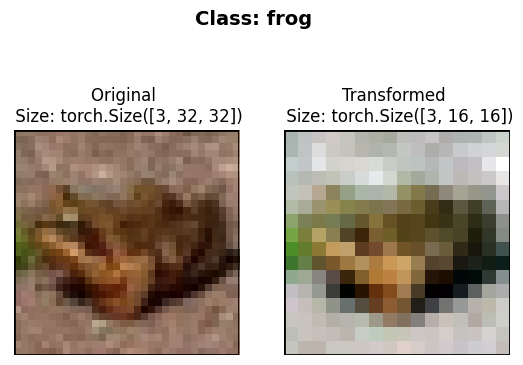

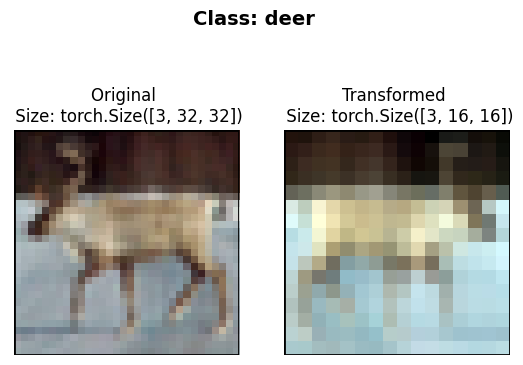

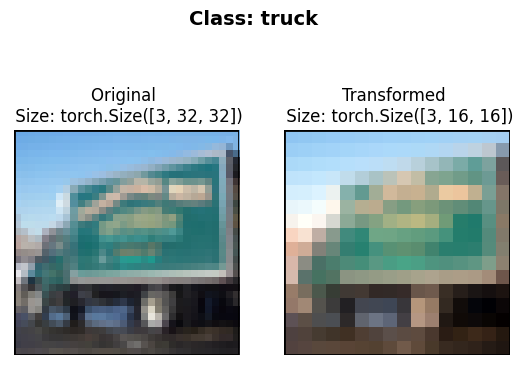

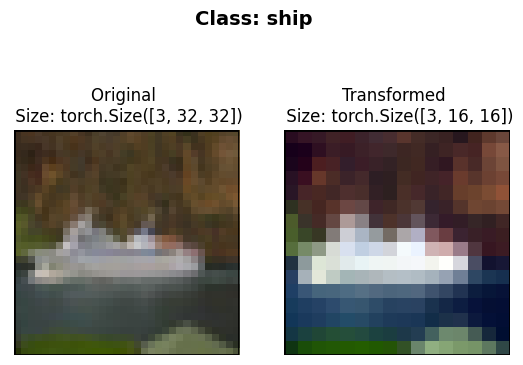

In [25]:
# TODO -- Define a compose transformation to resize the images to 3x16x16, normalize them using min/max normalization, and finally apply random horizontal flip

## ------------------------Your code begins here--------------------------------##
compose =compose =transforms.Compose([ transforms.Resize((16, 16)), transforms.Lambda(min_max_normalization),transforms.RandomHorizontalFlip()])

## ------------------------Your code ends here----------------------------------##

# ----------------------------- DONOT MODIFY CODE BELOW THIS LINE ---------------------------------- #
compare_images(cifar10_train, compose, cifar10_classes)

### 2.4.5 `TrivialAugment` for Data Augmentation (3 points)
We have seen a couple of transforms on the `CIFAR-10` dataset but there are plenty more. You can find them in [`torchvision.transforms` documentation](https://pytorch.org/vision/stable/transforms.html).

**Data augmentation** is the process of altering your data in such a way that you *artificiallly* increase the diversity of your training set.

Training a model on this *artificially* altered dataset (hopefully) results in a model that is capable of better *generalization*.

Machine Learning is all about harnessing the power of randomness and research shows that random transforms like [`transforms.TrivialAugmentWide()`](https://pytorch.org/vision/main/generated/torchvision.transforms.TrivialAugmentWide.html) generally perform better than hand-picked transforms. (*It is encouraged to explore the effectiveness of this method from its [original paper](https://arxiv.org/abs/2103.10158)*).

The idea behind this approach is to **randomly** pick transforms from a set of pre-existing ones and apply them on an image at **random** orders of magnitudes.

In this section we are going see `TrivialAugmentWide()` in live action!

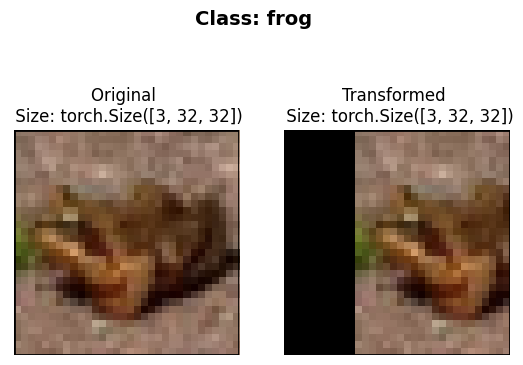

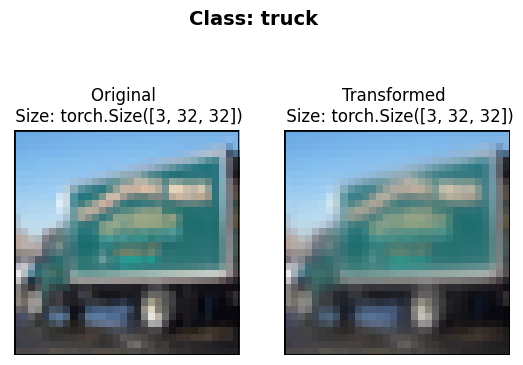

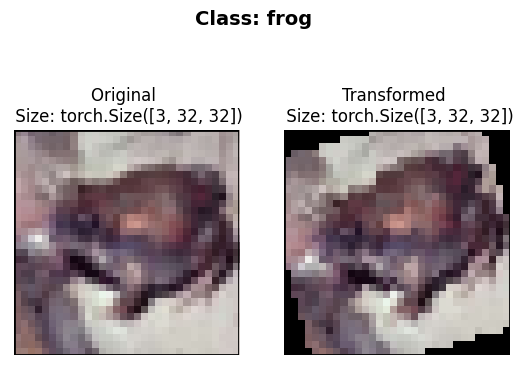

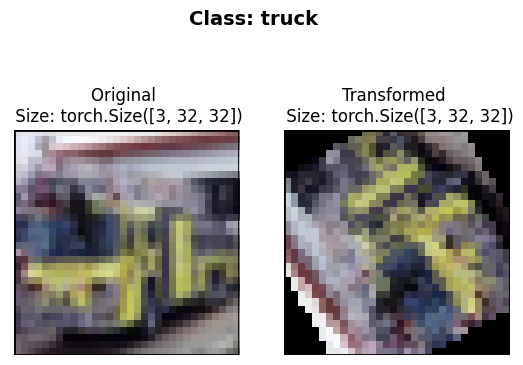

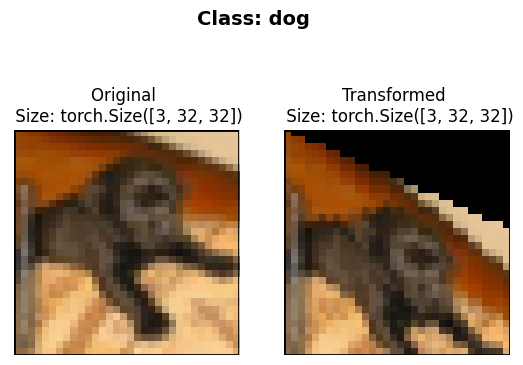

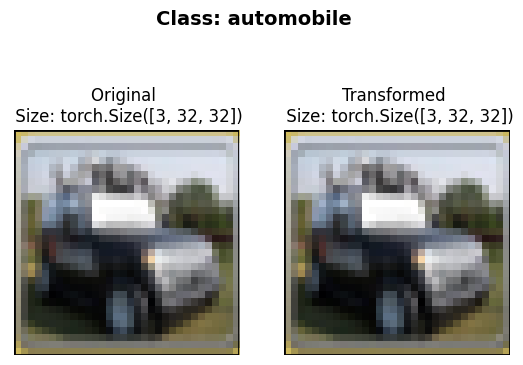

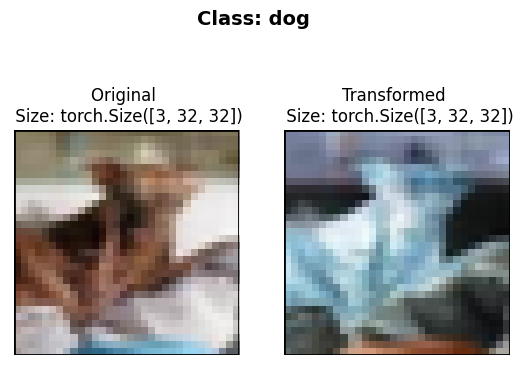

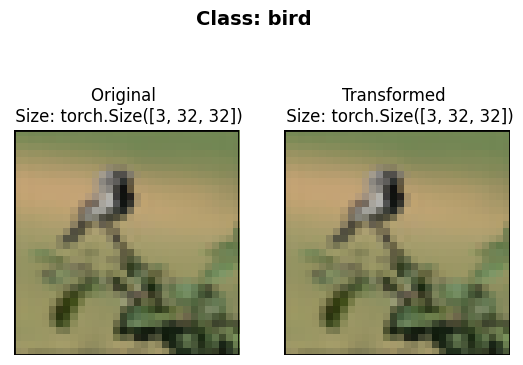

In [35]:
import torchvision.transforms as transforms

# TODO -- Define a transformation using transforms.TrivialAugmentationWide()
# TODO -- Experiment around with different values of the parameter 'num_magnitude_bins' but do not exceed 10

## ------------------------Your code begins here -------------------------------##
# trivial_augmentation = transforms.Compose([
#     transforms.ToPILImage(),
#     transforms.TrivialAugmentWide(num_magnitude_bins=1),
#     transforms.ToTensor()
# ])

# trivial_augmentation = transforms.Compose([
#     transforms.ToPILImage(),
#     transforms.TrivialAugmentWide(num_magnitude_bins=3),
#     transforms.ToTensor()
# ])
# trivial_augmentation = transforms.Compose([
#     transforms.ToPILImage(),
#     transforms.TrivialAugmentWide(num_magnitude_bins=5),
#     transforms.ToTensor()
# ])
# trivial_augmentation = transforms.Compose([
#     transforms.ToPILImage(),
#     transforms.TrivialAugmentWide(num_magnitude_bins=7),
#     transforms.ToTensor()
# ])
trivial_augmentation = transforms.Compose([
    transforms.ToPILImage(),
    transforms.TrivialAugmentWide(num_magnitude_bins=10),
    transforms.ToTensor()
])
## ------------------------Your code ends here----------------------------------##

# ----------------------------- DONOT MODIFY CODE BELOW THIS LINE ---------------------------------- #
compare_images(cifar10_train, trivial_augmentation, cifar10_classes, n=8)

## 2.5: PyTorch `DataLoaders`  - CLO4 (5 points)
As the name suggests, `Dataloader`s are used to load data into a model for training and inference. <br>
`Dataloaders` turn the large `Dataset` into smaller chunks called **batches** or **mini-batches** and can be set by `BATCH_SIZE` parameter. <br>
We perform this operation because it is *computationally efficient* to load *smaller chunks* of data into the model and perform impovements rather than loading all of the data at once.

In this subsection, we are going to create a `Dataloader` for the `cifar10` dataset.

In [36]:
# Setup the batch size hyperparameter
BATCH_SIZE = 32

# TODO - Turn dataset into batches (iterable) using torch.utils.DataLoader()

## ------------------------Your code begins here--------------------------------##
dataloader =torch.utils.data.DataLoader(cifar10_train, batch_size=BATCH_SIZE, shuffle=True)
## ------------------------Your code ends here----------------------------------##

# ----------------------------- DONOT MODIFY CODE BELOW THIS LINE ---------------------------------- #
# Lets check what we have created
print(f"Length of dataloader: {len(dataloader)} batches of size {BATCH_SIZE}")
# Check out what's inside the dataloader
features_batch, labels_batch = next(iter(dataloader))
print(f"Batch features shape: {features_batch.shape}, Batch labels shape: {labels_batch.shape}")

Length of dataloader: 1563 batches of size 32
Batch features shape: torch.Size([32, 3, 32, 32]), Batch labels shape: torch.Size([32])
